<h1><center>ML Project (Ecommerce Analysis)</center></h1>
<center>The objective of this project is to demonstrate the analysis of ecommerce data. The project aims to show how ecommerce data can be visualised and time-series forecasting can be applied to predict sales growth.</center>
<br>

<h3><center>By: Gee Jun Hui Leonidas Yunani</center></h3>
<center>Email: leonidas.gee@studio.unibo.it</center>
<center>Academic Year: 2021 / 2022</center>

In [1]:
# !pip install plotly==5.1.0
# !pip install pmdarima
# !pip install geopy

In [2]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
from pmdarima.arima import auto_arima
from datetime import timedelta
from geopy.geocoders import ArcGIS
geolocator = ArcGIS()

# Set the mode to online or offline
mode = 'offline' # online # offline

## Data Import

The [dataset](https://www.kaggle.com/olistbr/brazilian-ecommerce/home?select=olist_order_reviews_dataset.csv) used is provided by Olist, the largest department store in Brazilian marketplaces. Olist connects small businesses from all over Brazil to channels without hassle and with a single contract. Those merchants are able to sell their products through the Olist Store and ship them directly to the customers using Olist logistics partners.

In [3]:
# Load the datasets
customers = pd.read_csv('dataset/olist_customers_dataset.csv')
orders = pd.read_csv('dataset/olist_orders_dataset.csv')
items = pd.read_csv('dataset/olist_order_items_dataset.csv')
products = pd.read_csv('dataset/olist_products_dataset.csv')
categories = pd.read_csv('dataset/product_category_name_translation.csv')
payments = pd.read_csv('dataset/olist_order_payments_dataset.csv')

In [4]:
# Preview the customers dataset
print('Numbers of rows & columns: {}'.format(customers.shape))
print(list(customers.columns))

Numbers of rows & columns: (99441, 5)
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [5]:
# Preview the orders dataset
print('Numbers of rows & columns: {}'.format(orders.shape))
print(list(orders.columns))

Numbers of rows & columns: (99441, 8)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [6]:
# Preview the items dataset
print('Numbers of rows & columns: {}'.format(items.shape))
print(list(items.columns))

Numbers of rows & columns: (112650, 7)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [7]:
# Preview the products dataset
print('Numbers of rows & columns: {}'.format(products.shape))
print(list(products.columns))

Numbers of rows & columns: (32951, 9)
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [8]:
# Preview the categories dataset
print('Numbers of rows & columns: {}'.format(categories.shape))
print(list(categories.columns))

Numbers of rows & columns: (71, 2)
['product_category_name', 'product_category_name_english']


In [9]:
# Preview the payments dataset
print('Numbers of rows & columns: {}'.format(payments.shape))
print(list(payments.columns))

Numbers of rows & columns: (103886, 5)
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


## Data Preparation

In [10]:
# Inner join all the tables
data = customers.merge(orders, on='customer_id')
data = data.merge(items, on='order_id')
data = data.merge(products, on='product_id')
data = data.merge(categories, on='product_category_name')
data = data.merge(payments, on='order_id')
print('Number of rows & columns: {}'.format(data.shape))

Number of rows & columns: (115878, 31)


In [11]:
# Rearrange the columns
data = data[['order_purchase_timestamp', 'customer_unique_id', 'customer_state',    
             'product_category_name_english', 'payment_type', 'price', 'order_item_id']]

# Rename the columns
data.columns = ['Date', 'Customer', 'State', 'Product', 'Payment', 'Price', 'Orders']

In [12]:
# Replace the state codes with state names
states = {'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia', 
          'CE': 'Ceará', 'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás', 'MA': 'Maranhão', 
          'MT': 'Mato Grosso', 'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 
          'PR': 'Paraná', 'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte', 
          'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina', 'SP': 'São Paulo', 
          'SE': 'Sergipe', 'TO': 'Tocantins'}

data['State'] = data['State'].replace(states)

In [13]:
# Change the customer id into unique integer keys
le = LabelEncoder()
data['Customer'] = le.fit_transform(data['Customer'])

In [14]:
# Replace underscores with spaces
data['Product'] = data['Product'].str.replace('_', ' ')
data['Payment'] = data['Payment'].str.replace('_', ' ')

# Change strings to camel case
data['Product'] = data['Product'].str.title()
data['Payment'] = data['Payment'].str.title()

In [15]:
# Keep only the date part from date
data['Date'] = pd.to_datetime(data['Date']).dt.date

# Add a sales column
data['Sales'] = data['Orders'] * data['Price']

In [16]:
# Sort transactions by date
data = data.sort_values(by='Date', ignore_index=True)

# Preview the dataset
print('Number of rows & columns: {}'.format(data.shape))
data.head(3)

Number of rows & columns: (115878, 8)


,Date,Customer,State,Product,Payment,Price,Orders,Sales
0,2016-09-04,67670,Roraima,Furniture Decor,Credit Card,32.90,2,65.80
1,2016-09-04,67670,Roraima,Furniture Decor,Credit Card,39.99,1,39.99
2,2016-09-05,26676,Rio Grande do Sul,Telephony,Credit Card,59.50,1,59.50


## Data Visualisation

### Customer by Payment

Customers can be divided by payment into 4 categories. It can be seen that most customers pay using credit cards and a local payment system called Boletao in Brazil.

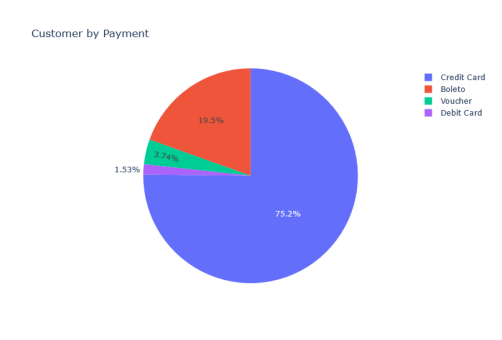

In [17]:
# Plot the customer by payment graph
if mode == 'online':
    # Get the customer by payment
    group_df = data[['Payment', 'Customer']].groupby('Payment').agg('nunique')
    customer_by_payment = pd.DataFrame()
    customer_by_payment['Payment'] = group_df.index
    customer_by_payment['Customer'] = group_df.values

    fig = px.pie(customer_by_payment, values='Customer', names='Payment', title='Customer by Payment')
    fig.show()
    
elif mode == 'offline':
    plt.figure(figsize=(14, 6))
    image = plt.imread('images/customer_by_payment.png')
    plt.axis('off')
    plt.imshow(image)

### Orders by Product

Using an icicle chart, the products with the most orders can be shown. Based on the chart, the top 5 products include Bed Bath Table, Furniture Decor, Health Beauty, Sports Leisure and Computers Accessories.

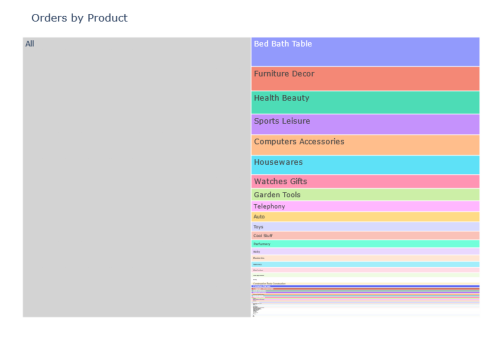

In [18]:
# Plot the orders by product graph
if mode == 'online':
    # Get the orders by product
    group_df = data[['Product', 'Orders']].groupby('Product').agg('sum')
    orders_by_product = pd.DataFrame()
    orders_by_product['Product'] = group_df.index
    orders_by_product['Orders'] = group_df.values

    fig = px.icicle(orders_by_product, values='Orders', path=[px.Constant('All'), 'Product'], title='Orders by Product')
    fig.update_traces(root_color="lightgrey")
    fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
    fig.show()
    
elif mode == 'offline':
    plt.figure(figsize=(14, 6))
    image = plt.imread('images/orders_by_product.png')
    plt.axis('off')
    plt.imshow(image)

### Sales by State

Based on a bubble map, the location and size of sales from customers throughout the states in Brazil can be visualised. São Paulo, Rio de Janeiro and Minas Gerais are the states with the largest sales from customers.

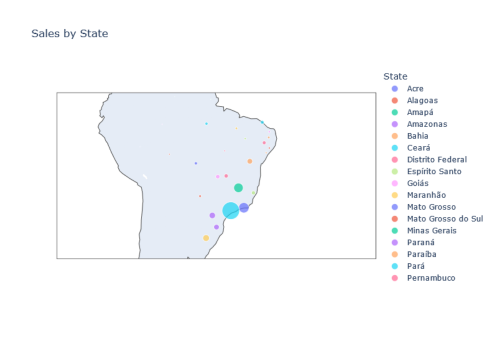

In [19]:
# Plot the sales by state graph
if mode == 'online':
    # Get the sales by state
    group_df = data[['State', 'Sales']].groupby('State').agg('sum')
    sales_by_state = pd.DataFrame()
    sales_by_state['State'] = group_df.index
    sales_by_state['Sales'] = group_df.values

    def get_location(args):
        location = geolocator.geocode(args[0] + ', Brazil')
        return pd.Series([args[0], location.longitude, location.latitude, args[1]])

    sales_by_state[['State', 'Longitude', 'Latitude', 'Sales']] = sales_by_state.apply(get_location, axis=1)

    fig = px.scatter_geo(sales_by_state, lon='Longitude', lat='Latitude',
                         color='State', hover_name='State', size='Sales',
                         projection='natural earth', title='Sales by State')
    fig.show()
    
elif mode == 'offline':
    plt.figure(figsize=(14, 6))
    image = plt.imread('images/sales_by_state.png')
    plt.axis('off')
    plt.imshow(image)

## Time Series Forecasting

### Predicting Sales Growth

Using ARIMA, a model can be trained to forecast the future weekly sales over a future period of 30 days. Auto ARIMA is used to find the optimal values for the model using data from 2017 to August, 2018.

- Auto-Regressive (p) -> Number of autoregressive terms.

- Integrated (d) -> Number of nonseasonal differences needed for stationarity.

- Moving Average (q) -> Number of lagged forecast errors in the prediction equation.

The optimal parameters are then used to forecast the future weekly users over 8 weeks.

In [20]:
# Get the number of weekly sales
data['Date'] = pd.to_datetime(data['Date']) - pd.to_timedelta(7, unit='d')
group_df = data[['Date', 'Sales']].groupby(pd.Grouper(key='Date', freq='W-MON')).agg('sum')
weekly_sales = pd.DataFrame()
weekly_sales['Date'] = group_df.index
weekly_sales['Date'] = pd.to_datetime(weekly_sales['Date'])
weekly_sales['Sales'] = group_df.values

In [21]:
# Keep rows starting from 2017 and ending in August, 2018
weekly_sales = weekly_sales[(weekly_sales['Date'].dt.year >= 2017) & (weekly_sales['Date'] <= '2018-07-30')]
weekly_sales = weekly_sales.reset_index(drop=True)
weekly_sales

,Date,Sales
0,2017-01-02,7030.05
1,2017-01-09,16959.61
2,2017-01-16,33800.16
3,2017-01-23,77808.35
4,2017-01-30,71230.95
...,...,...
78,2018-07-02,174093.09
79,2018-07-09,208739.37
80,2018-07-16,266542.56
81,2018-07-23,281070.82


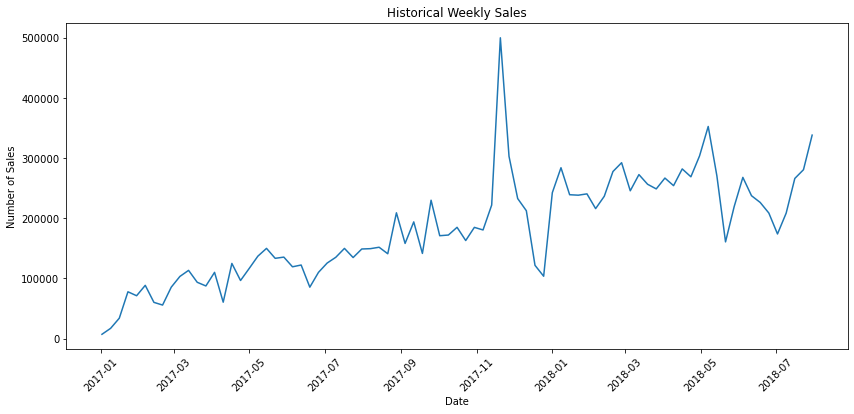

In [22]:
# Plot the graph of the weekly sales
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales['Date'], weekly_sales['Sales'])
plt.xticks(rotation=45)
plt.title('Historical Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Number of Sales')
plt.show()

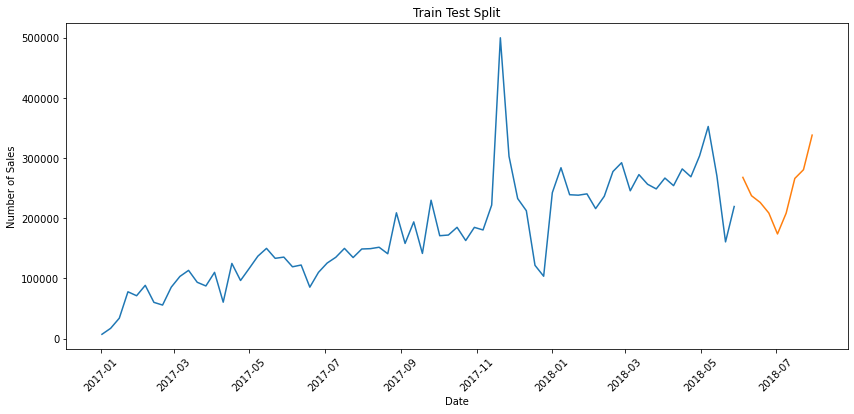

In [23]:
# Split the dataset into train and test
def train_test_split(data, ratio):
    size = int(len(data) * ratio)
    train, test = data[0:size], data[size:len(data)]
    return train, test

train, test = train_test_split(weekly_sales, 0.9)

plt.figure(figsize=(14, 6))
plt.plot(train['Date'], train['Sales'])
plt.plot(test['Date'], test['Sales'])
plt.xticks(rotation=45)
plt.title('Train Test Split')
plt.xlabel('Date')
plt.ylabel('Number of Sales')
plt.show()

In [24]:
# Fit and evaluate the best ARIMA model
arima_model = auto_arima(train['Sales'], stepwise=False, parallel=True)
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   74
Model:               SARIMAX(4, 1, 1)   Log Likelihood                -889.608
Date:                Sun, 18 Jul 2021   AIC                           1793.217
Time:                        22:59:09   BIC                           1809.250
Sample:                             0   HQIC                          1799.606
                                 - 74                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   5699.6398   1748.139      3.260      0.001    2273.350    9125.930
ar.L1          0.2385      0.167      1.429      0.153      -0.089       0.566
ar.L2         -0.1933      0.253     -0.765      0.444      -0.689       0.302
ar.L3         -0.1057      0.283     -0.373      0.709      -0.661       0.450
ar.L4         -0.3453      0.258     -1.338      0.181      -0.851       0.160
ma.L1         -0.8318      0.207     -4.025      0.000      -1.237      -0.427
sigma2      2.788e+09      0.005   5.69e+11      0.000    2.79e+09    2.79e+09
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               930.39
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               3.46   Skew:                             2.64
Prob(H) (two-sided):                  0.00   Kurtosis:                        19.68
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number  5e+26. Standard errors may be unstable.
"""

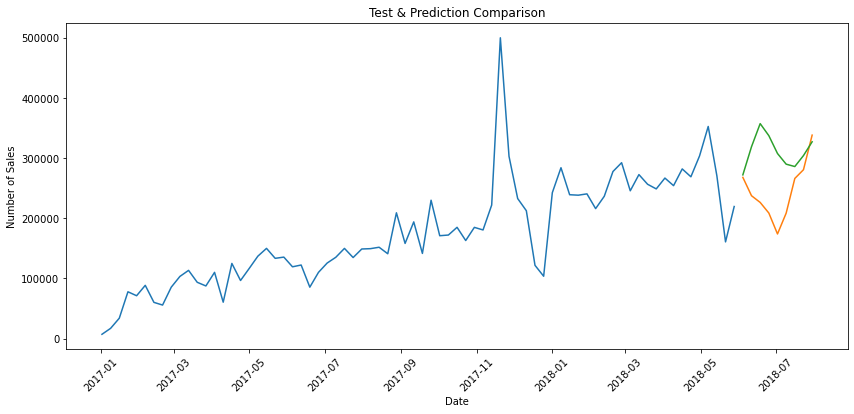

In [25]:
# Predict and compare to the test set
prediction = pd.DataFrame()
prediction['Date'] = test['Date']
prediction['Sales'] = arima_model.predict(n_periods=len(test))

plt.figure(figsize=(14, 6))
plt.plot(train['Date'], train['Sales'])
plt.plot(test['Date'], test['Sales'])
plt.plot(prediction['Date'], prediction['Sales'])
plt.xticks(rotation=45)
plt.title('Test & Prediction Comparison')
plt.xlabel('Date')
plt.ylabel('Number of Sales')
plt.show()

In [26]:
def get_forecast(data, y, n_periods):
    arima_model = auto_arima(data[y], stepwise=False, parallel=True)
    print(f"Best Model Parameters: {arima_model.get_params()['order']}")
    predictions = arima_model.predict(n_periods=n_periods)

    result = data.copy()
    result['Forecasted'] = False

    for value in predictions:
        last_row = result.loc[len(result)-1]
        result.loc[len(result)] = [last_row['Date'] + timedelta(days=7), round(value), True]
    
    return result

Best Model Parameters: (2, 1, 3)


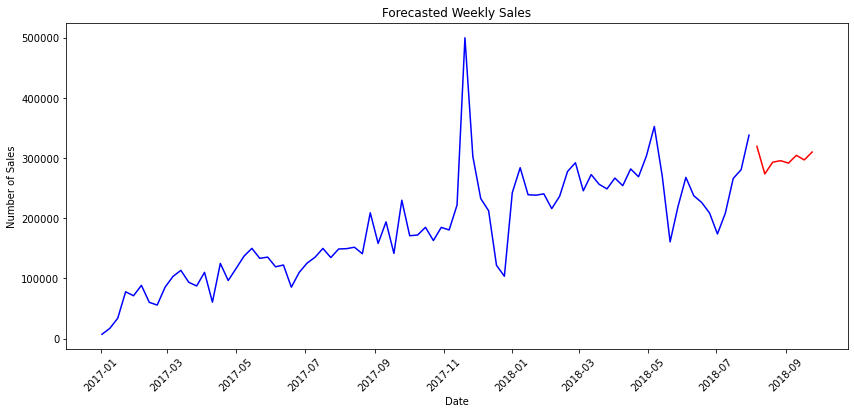

In [27]:
# Forecast future weekly sales for 8 weeks
sales_forecast = get_forecast(weekly_sales, 'Sales', 8)

# Plot the graph of the forecasted weekly sales
X1 = sales_forecast[sales_forecast.Forecasted == False]
X2 = sales_forecast[sales_forecast.Forecasted == True]

plt.figure(figsize=(14, 6))

plt.plot(X1['Date'], X1['Sales'], 'b')
plt.plot(X2['Date'], X2['Sales'], 'r')

plt.title('Forecasted Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.show()

## Conclusion

The demonstration shows how ecommerce data can be prepared for analysis and the application of machine learning methods to gain new insights. The charts can be more optimally visualised using data visualisation software such as Tableau and Microsoft BI in addition to data preparation and machine learning techniques via Python.